# 🔬 Complete Guide to Scikit-Learn Library

## What is Scikit-Learn?
Scikit-learn (sklearn) is the most popular machine learning library in Python. It provides:
- Simple and efficient tools for data mining and data analysis
- Built on NumPy, SciPy, and Matplotlib
- Open source, commercially usable - BSD license

## 📚 Major Modules in Scikit-Learn

| Module | Purpose |
|--------|---------|
| `sklearn.datasets` | Load and generate datasets |
| `sklearn.preprocessing` | Data preprocessing & feature scaling |
| `sklearn.model_selection` | Train/test split, cross-validation |
| `sklearn.linear_model` | Linear & Logistic Regression |
| `sklearn.tree` | Decision Trees |
| `sklearn.ensemble` | Random Forest, Gradient Boosting |
| `sklearn.svm` | Support Vector Machines |
| `sklearn.neighbors` | K-Nearest Neighbors |
| `sklearn.cluster` | K-Means, DBSCAN clustering |
| `sklearn.metrics` | Model evaluation metrics |
| `sklearn.pipeline` | Create ML pipelines |
| `sklearn.decomposition` | PCA, dimensionality reduction |
| `sklearn.feature_extraction` | Text/Image feature extraction |

In [1]:
# First, let's import all the essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"Scikit-learn version: {sklearn.__version__}")
print("✅ All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Scikit-learn version: 1.8.0
✅ All libraries imported successfully!


---
# 📊 Module 1: sklearn.datasets - Loading & Generating Data

Scikit-learn provides several ways to get data:
1. **Toy Datasets** - Small, classic datasets (iris, digits, boston)
2. **Real-world Datasets** - Larger datasets that need to be downloaded
3. **Generated Datasets** - Synthetic data for testing algorithms

In [2]:
# 1.1 Loading Toy Datasets
from sklearn.datasets import load_iris, load_digits, load_wine, load_breast_cancer

# Load the famous Iris dataset
iris = load_iris()

print("🌸 IRIS DATASET")
print("=" * 50)
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Data shape: {iris.data.shape}")  # (150 samples, 4 features)
print(f"Target shape: {iris.target.shape}")
print(f"\nFirst 5 samples:\n{iris.data[:5]}")

🌸 IRIS DATASET
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
Target shape: (150,)

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [3]:
# 1.2 Converting to Pandas DataFrame (More readable)
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in iris.target]

print("📊 Iris as DataFrame:")
iris_df.head(10)

📊 Iris as DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


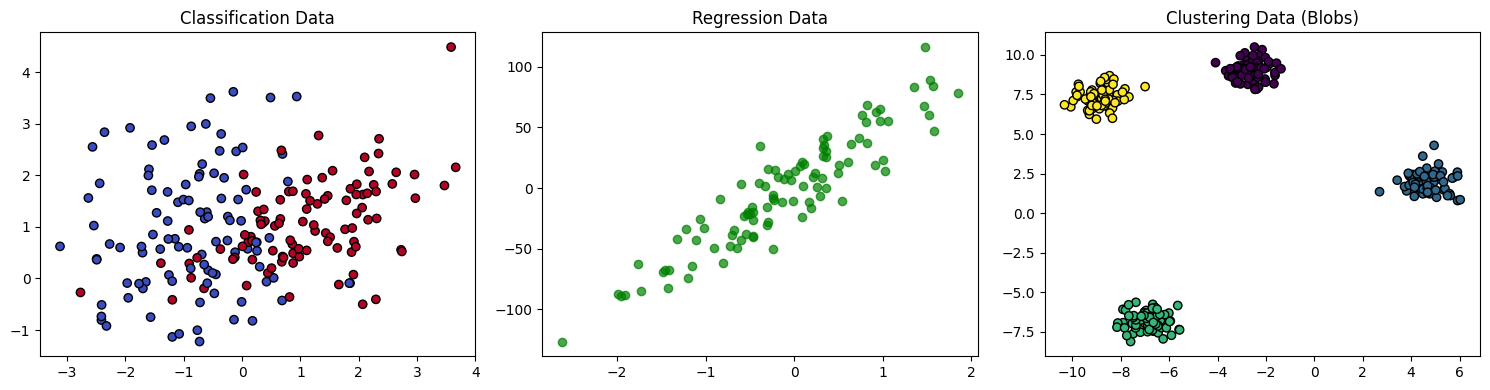

In [4]:
# 1.3 Generating Synthetic Datasets
from sklearn.datasets import make_classification, make_regression, make_blobs

# Generate classification data
X_clf, y_clf = make_classification(
    n_samples=200,      # Number of samples
    n_features=2,       # Number of features
    n_informative=2,    # Informative features
    n_redundant=0,      # Redundant features
    n_clusters_per_class=1,
    random_state=42
)

# Generate regression data
X_reg, y_reg = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)

# Generate clustering data (blobs)
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=4,          # Number of clusters
    cluster_std=0.60,
    random_state=42
)

# Visualize all three
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='coolwarm', edgecolor='k')
axes[0].set_title('Classification Data')

axes[1].scatter(X_reg, y_reg, color='green', alpha=0.7)
axes[1].set_title('Regression Data')

axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', edgecolor='k')
axes[2].set_title('Clustering Data (Blobs)')

plt.tight_layout()
plt.show()

---
# ⚙️ Module 2: sklearn.preprocessing - Data Preprocessing

Preprocessing is CRUCIAL before feeding data to ML models. Common techniques:
- **StandardScaler**: Standardize to mean=0, std=1 (z-score normalization)
- **MinMaxScaler**: Scale to a range [0, 1]
- **LabelEncoder**: Convert categorical labels to numbers
- **OneHotEncoder**: Create binary columns for categories
- **PolynomialFeatures**: Create polynomial features

In [5]:
# 2.1 StandardScaler - Standardization (Z-score normalization)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sample data with different scales
data = np.array([[100, 0.001],
                 [200, 0.002],
                 [300, 0.003],
                 [400, 0.004],
                 [500, 0.005]])

print("📌 Original Data:")
print(data)
print(f"\nMean: {data.mean(axis=0)}")
print(f"Std:  {data.std(axis=0)}")

# Apply StandardScaler
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

print("\n📌 After StandardScaler (mean=0, std=1):")
print(data_standardized)
print(f"\nNew Mean: {data_standardized.mean(axis=0).round(2)}")
print(f"New Std:  {data_standardized.std(axis=0).round(2)}")

📌 Original Data:
[[1.e+02 1.e-03]
 [2.e+02 2.e-03]
 [3.e+02 3.e-03]
 [4.e+02 4.e-03]
 [5.e+02 5.e-03]]

Mean: [3.e+02 3.e-03]
Std:  [1.41421356e+02 1.41421356e-03]

📌 After StandardScaler (mean=0, std=1):
[[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]

New Mean: [ 0. -0.]
New Std:  [1. 1.]


In [6]:
# 2.2 MinMaxScaler - Normalization (Scale to [0, 1])
minmax_scaler = MinMaxScaler()
data_normalized = minmax_scaler.fit_transform(data)

print("📌 After MinMaxScaler (range [0, 1]):")
print(data_normalized)
print(f"\nMin: {data_normalized.min(axis=0)}")
print(f"Max: {data_normalized.max(axis=0)}")

📌 After MinMaxScaler (range [0, 1]):
[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [0.75 0.75]
 [1.   1.  ]]

Min: [0. 0.]
Max: [1. 1.]


In [7]:
# 2.3 LabelEncoder - Convert categories to numbers
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Categorical data
colors = ['red', 'green', 'blue', 'red', 'green', 'blue', 'red']

label_encoder = LabelEncoder()
colors_encoded = label_encoder.fit_transform(colors)

print("📌 LabelEncoder Example:")
print(f"Original: {colors}")
print(f"Encoded:  {colors_encoded}")
print(f"Classes:  {label_encoder.classes_}")

# Inverse transform
print(f"Decoded:  {label_encoder.inverse_transform([0, 1, 2])}")

📌 LabelEncoder Example:
Original: ['red', 'green', 'blue', 'red', 'green', 'blue', 'red']
Encoded:  [2 1 0 2 1 0 2]
Classes:  ['blue' 'green' 'red']
Decoded:  ['blue' 'green' 'red']


In [8]:
# 2.4 OneHotEncoder - Create binary columns (for ML models that need it)
from sklearn.preprocessing import OneHotEncoder

# Reshape for OneHotEncoder
colors_array = np.array(colors).reshape(-1, 1)

onehot_encoder = OneHotEncoder(sparse_output=False)
colors_onehot = onehot_encoder.fit_transform(colors_array)

print("📌 OneHotEncoder Example:")
print(f"Categories: {onehot_encoder.categories_[0]}")
print(f"\nOne-Hot Encoded:\n{colors_onehot}")

# As a DataFrame for clarity
onehot_df = pd.DataFrame(colors_onehot, columns=onehot_encoder.categories_[0])
onehot_df['original'] = colors
print("\n📊 As DataFrame:")
onehot_df

📌 OneHotEncoder Example:
Categories: ['blue' 'green' 'red']

One-Hot Encoded:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

📊 As DataFrame:


,blue,green,red,original
0,0.0,0.0,1.0,red
1,0.0,1.0,0.0,green
2,1.0,0.0,0.0,blue
3,0.0,0.0,1.0,red
4,0.0,1.0,0.0,green
5,1.0,0.0,0.0,blue
6,0.0,0.0,1.0,red


---
# 🔀 Module 3: sklearn.model_selection - Train/Test Split & Cross-Validation

**Key Functions:**
- `train_test_split()` - Split data into training and testing sets
- `cross_val_score()` - Perform k-fold cross-validation
- `GridSearchCV` - Hyperparameter tuning with grid search
- `RandomizedSearchCV` - Random hyperparameter search

In [9]:
# 3.1 Train/Test Split
from sklearn.model_selection import train_test_split

# Using Iris dataset
X = iris.data
y = iris.target

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class proportions
)

print("📌 Train/Test Split Results:")
print(f"Total samples: {len(X)}")
print(f"Training set:  {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing set:   {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

# Check class distribution
print(f"\n📊 Class distribution in y_train: {np.bincount(y_train)}")
print(f"📊 Class distribution in y_test:  {np.bincount(y_test)}")

📌 Train/Test Split Results:
Total samples: 150
Training set:  120 samples (80%)
Testing set:   30 samples (20%)

📊 Class distribution in y_train: [40 40 40]
📊 Class distribution in y_test:  [10 10 10]


📌 5-Fold Cross-Validation Results:
Scores for each fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean accuracy: 0.9733
Standard deviation: 0.0249


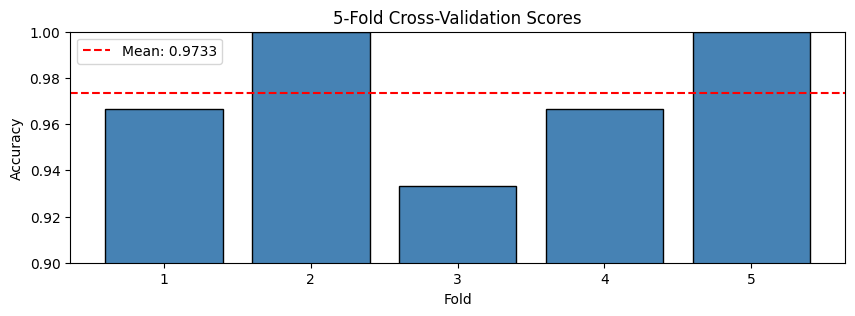

In [10]:
# 3.2 Cross-Validation
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression

# Create a model
model = LogisticRegression(max_iter=200)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)

print("📌 5-Fold Cross-Validation Results:")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Visualize the folds
plt.figure(figsize=(10, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.legend()
plt.ylim(0.9, 1.0)
plt.show()

---
# 📈 Module 4: sklearn.linear_model - Linear Models

**Common Models:**
- `LinearRegression` - For regression tasks
- `LogisticRegression` - For classification tasks
- `Ridge`, `Lasso` - Regularized regression
- `SGDClassifier`, `SGDRegressor` - Stochastic Gradient Descent

📌 Linear Regression Results:
Coefficient (slope): 2.4197
Intercept: 5.2858
Equation: y = 2.42x + 5.29

📊 Model Performance:
Mean Squared Error: 2.6148
R² Score: 0.9546


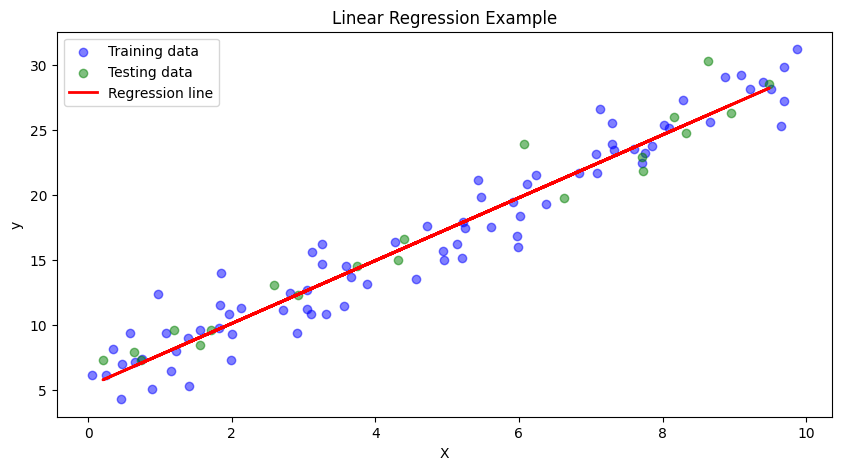

In [11]:
# 4.1 Linear Regression Example
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample data
np.random.seed(42)
X_lr = np.random.rand(100, 1) * 10  # Features
y_lr = 2.5 * X_lr.squeeze() + np.random.randn(100) * 2 + 5  # y = 2.5x + 5 + noise

# Split the data
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)

# Make predictions
y_pred_lr = linear_model.predict(X_test_lr)

# Model parameters
print("📌 Linear Regression Results:")
print(f"Coefficient (slope): {linear_model.coef_[0]:.4f}")
print(f"Intercept: {linear_model.intercept_:.4f}")
print(f"Equation: y = {linear_model.coef_[0]:.2f}x + {linear_model.intercept_:.2f}")

# Metrics
print(f"\n📊 Model Performance:")
print(f"Mean Squared Error: {mean_squared_error(y_test_lr, y_pred_lr):.4f}")
print(f"R² Score: {r2_score(y_test_lr, y_pred_lr):.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(X_train_lr, y_train_lr, color='blue', alpha=0.5, label='Training data')
plt.scatter(X_test_lr, y_test_lr, color='green', alpha=0.5, label='Testing data')
plt.plot(X_test_lr, y_pred_lr, color='red', linewidth=2, label='Regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Example')
plt.legend()
plt.show()

📌 Logistic Regression Results:
Accuracy: 0.9667

📊 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



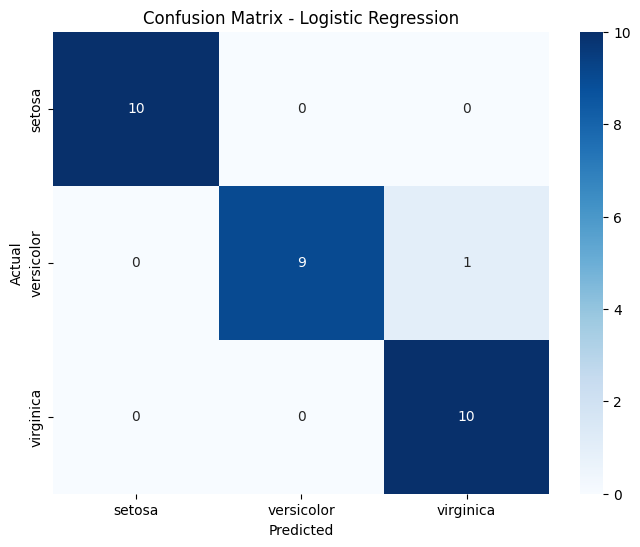

In [12]:
# 4.2 Logistic Regression (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Using Iris dataset (already split above)
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

print("📌 Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

---
# 🌳 Module 5: sklearn.tree - Decision Trees

Decision Trees are intuitive models that make decisions based on feature thresholds.
- `DecisionTreeClassifier` - For classification
- `DecisionTreeRegressor` - For regression

**Key Parameters:**
- `max_depth` - Maximum depth of tree
- `min_samples_split` - Minimum samples to split a node
- `criterion` - 'gini' or 'entropy' for classification

📌 Decision Tree Results:
Accuracy: 0.9667
Feature Importances: {'sepal length (cm)': np.float64(0.0), 'sepal width (cm)': np.float64(0.0), 'petal length (cm)': np.float64(0.579), 'petal width (cm)': np.float64(0.421)}


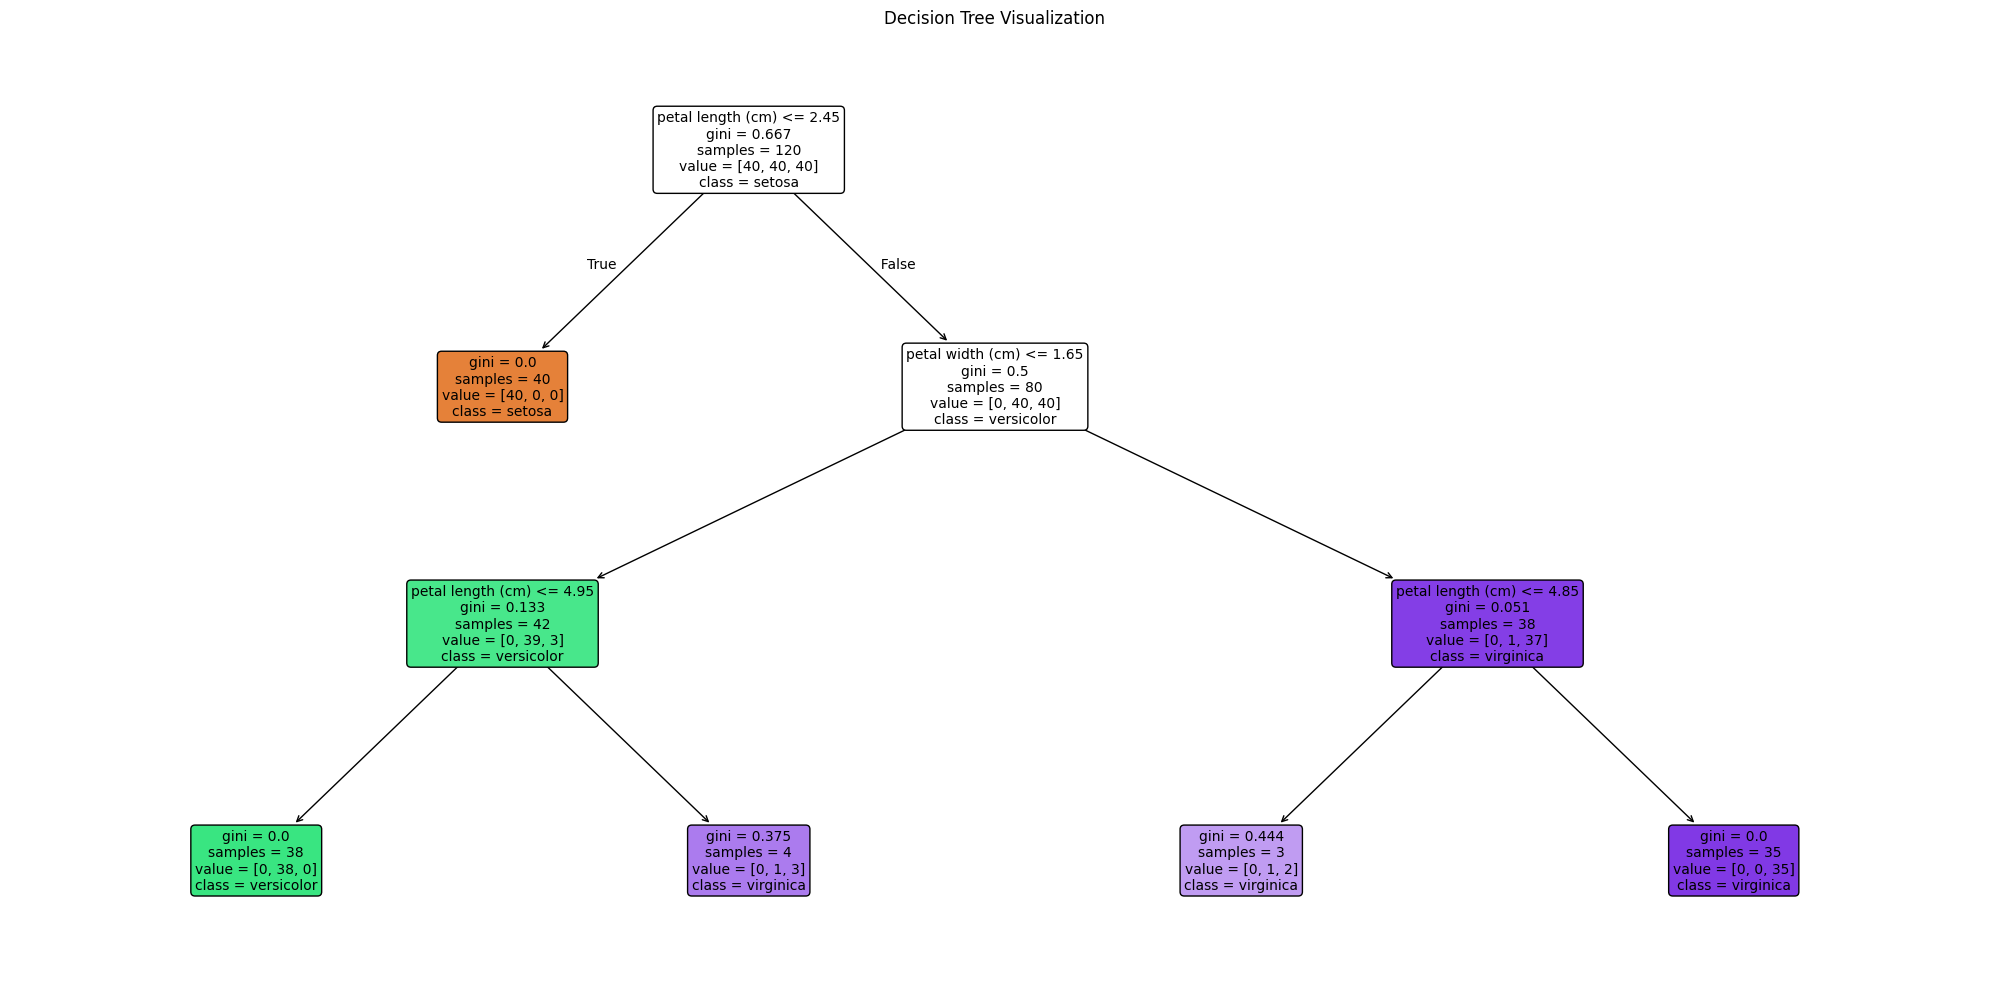

In [13]:
# 5.1 Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Create and train model
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_classifier.predict(X_test)

print("📌 Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Feature Importances: {dict(zip(iris.feature_names, dt_classifier.feature_importances_.round(3)))}")

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names,
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

---
# 🌲 Module 6: sklearn.ensemble - Ensemble Methods

Ensemble methods combine multiple models for better performance:
- `RandomForestClassifier/Regressor` - Bagging of decision trees
- `GradientBoostingClassifier/Regressor` - Sequential boosting
- `AdaBoostClassifier/Regressor` - Adaptive boosting
- `VotingClassifier` - Combine different model types

📌 Random Forest Results:
Accuracy: 0.9333


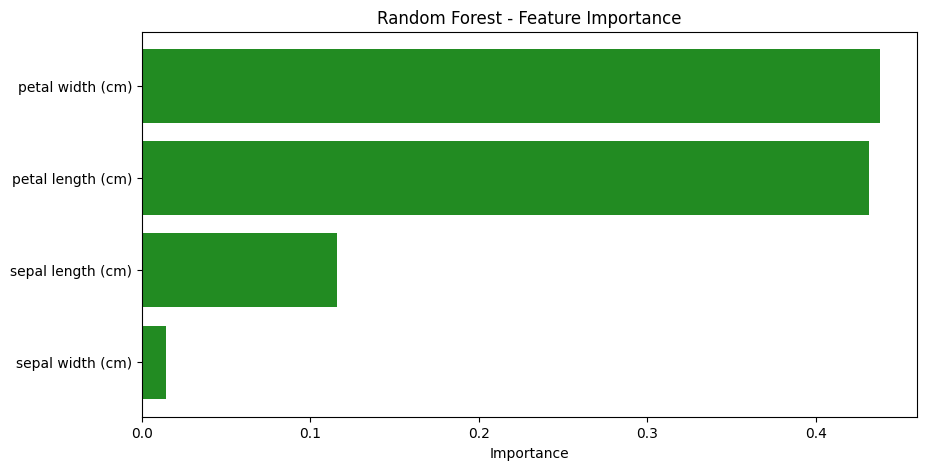


📊 Feature Importance Table:


,feature,importance
3,petal width (cm),0.438141
2,petal length (cm),0.431641
0,sepal length (cm),0.115972
1,sepal width (cm),0.014246


In [14]:
# 6.1 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rf_classifier = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    max_depth=5,
    random_state=42
)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

print("📌 Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.show()

print("\n📊 Feature Importance Table:")
feature_importance

---
# 🎯 Module 7: sklearn.svm - Support Vector Machines

SVMs find the optimal hyperplane to separate classes:
- `SVC` - Support Vector Classification
- `SVR` - Support Vector Regression
- `LinearSVC` - Linear SVM (faster for large datasets)

**Key Parameters:**
- `kernel` - 'linear', 'rbf', 'poly', 'sigmoid'
- `C` - Regularization parameter
- `gamma` - Kernel coefficient

📌 SVM Results with Different Kernels:
  linear    : 1.0000
  rbf       : 0.9667
  poly      : 0.9667


C:\Users\z0055hnx\AppData\Roaming\Python\Python313\site-packages\sklearn\inspection\_plot\decision_boundary.py:225: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(
C:\Users\z0055hnx\AppData\Roaming\Python\Python313\site-packages\sklearn\inspection\_plot\decision_boundary.py:225: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(
C:\Users\z0055hnx\AppData\Roaming\Python\Python313\site-packages\sklearn\inspection\_plot\decision_boundary.py:225: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(


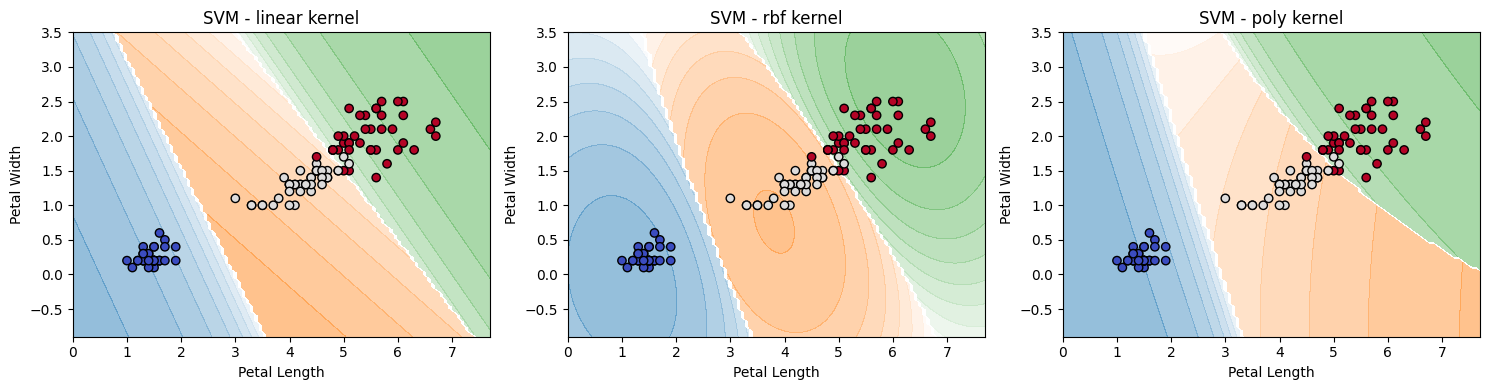

In [15]:
# 7.1 Support Vector Classifier
from sklearn.svm import SVC

# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)
    results[kernel] = accuracy_score(y_test, y_pred_svm)

print("📌 SVM Results with Different Kernels:")
for kernel, acc in results.items():
    print(f"  {kernel:10}: {acc:.4f}")

# Visualize SVM decision boundary (using only 2 features for visualization)
from sklearn.inspection import DecisionBoundaryDisplay

# Use only 2 features for visualization
X_2d = X[:, 2:4]  # petal length and petal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, kernel in enumerate(kernels):
    svm_2d = SVC(kernel=kernel, random_state=42)
    svm_2d.fit(X_train_2d, y_train_2d)
    
    DecisionBoundaryDisplay.from_estimator(
        svm_2d, X_train_2d, ax=axes[idx], alpha=0.5, cmap='coolwarm'
    )
    axes[idx].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, edgecolor='k', cmap='coolwarm')
    axes[idx].set_title(f'SVM - {kernel} kernel')
    axes[idx].set_xlabel('Petal Length')
    axes[idx].set_ylabel('Petal Width')

plt.tight_layout()
plt.show()

---
# 👥 Module 8: sklearn.neighbors - K-Nearest Neighbors

KNN classifies based on the majority class of k nearest neighbors:
- `KNeighborsClassifier` - For classification
- `KNeighborsRegressor` - For regression

**Key Parameters:**
- `n_neighbors` - Number of neighbors (k)
- `weights` - 'uniform' or 'distance'
- `metric` - Distance metric ('euclidean', 'manhattan', etc.)

📌 Best K: 3 with accuracy: 1.0000


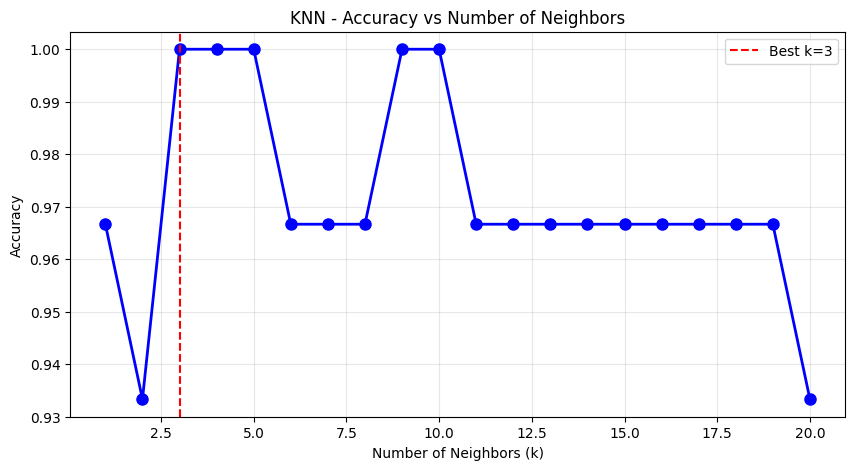

In [16]:
# 8.1 K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Test different values of k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

# Find best k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"📌 Best K: {best_k} with accuracy: {best_accuracy:.4f}")

# Visualize accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN - Accuracy vs Number of Neighbors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# 🔮 Module 9: sklearn.cluster - Clustering (Unsupervised Learning)

Clustering groups similar data points without labels:
- `KMeans` - Partition into k clusters
- `DBSCAN` - Density-based clustering
- `AgglomerativeClustering` - Hierarchical clustering
- `MeanShift` - Mean-shift clustering

📌 K-Means Clustering
Cluster Centers:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]
Inertia (within-cluster sum of squares): 203.89
Silhouette Score: 0.8756


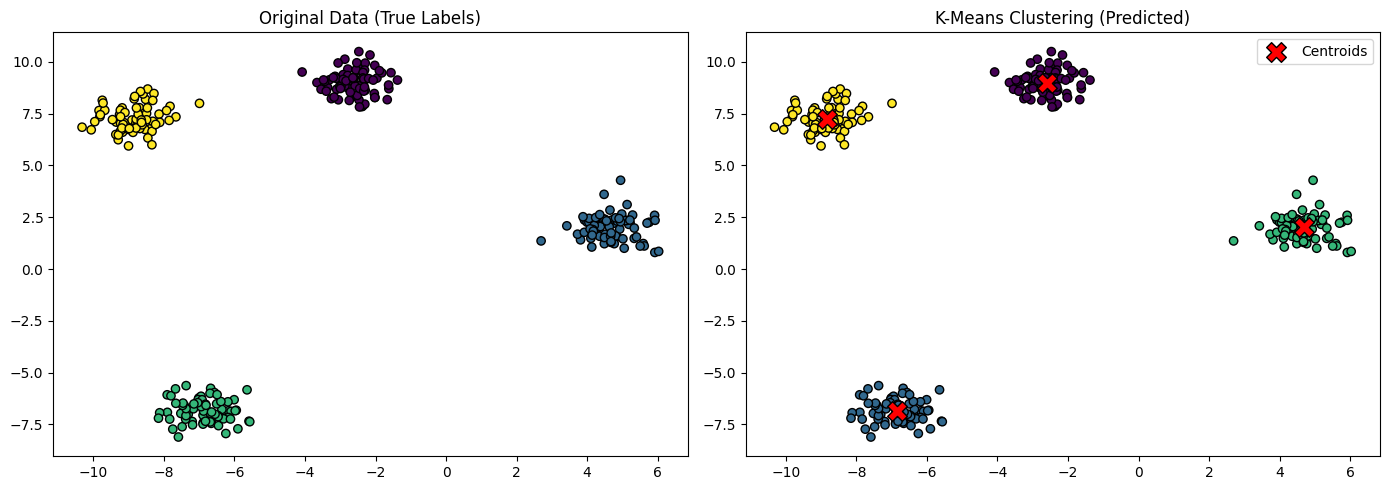

In [17]:
# 9.1 K-Means Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Use the blob data we generated earlier
print("📌 K-Means Clustering")

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_blobs)

print(f"Cluster Centers:\n{kmeans.cluster_centers_}")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_blobs, cluster_labels):.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data (with true labels)
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', edgecolor='k')
axes[0].set_title('Original Data (True Labels)')

# K-Means clustering result
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k')
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, edgecolor='black', label='Centroids')
axes[1].set_title('K-Means Clustering (Predicted)')
axes[1].legend()

plt.tight_layout()
plt.show()

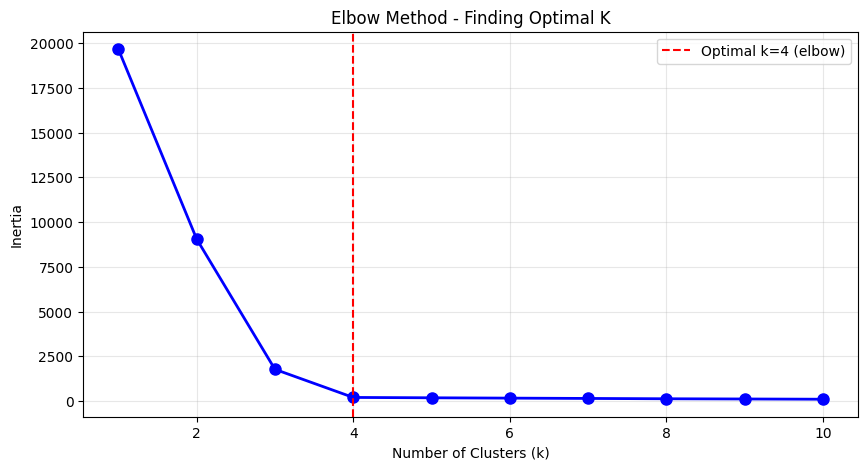

📌 The 'elbow' in the curve suggests the optimal number of clusters!


In [18]:
# 9.2 Elbow Method - Finding Optimal Number of Clusters
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_blobs)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K')
plt.axvline(x=4, color='red', linestyle='--', label='Optimal k=4 (elbow)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("📌 The 'elbow' in the curve suggests the optimal number of clusters!")

---
# 📏 Module 10: sklearn.metrics - Model Evaluation

**Classification Metrics:**
- `accuracy_score` - Overall correctness
- `precision_score` - Positive predictive value
- `recall_score` - True positive rate
- `f1_score` - Harmonic mean of precision and recall
- `confusion_matrix` - Actual vs predicted matrix
- `roc_auc_score` - Area under ROC curve

**Regression Metrics:**
- `mean_squared_error` (MSE)
- `mean_absolute_error` (MAE)
- `r2_score` - Coefficient of determination

📌 Classification Metrics Explained:
Accuracy:  0.8500  - Overall correct predictions
Precision: 0.8767  - Of predicted positives, how many are correct
Recall:    0.8258  - Of actual positives, how many were found
F1 Score:  0.8505  - Harmonic mean of precision and recall
ROC-AUC:   0.9142  - Area under ROC curve


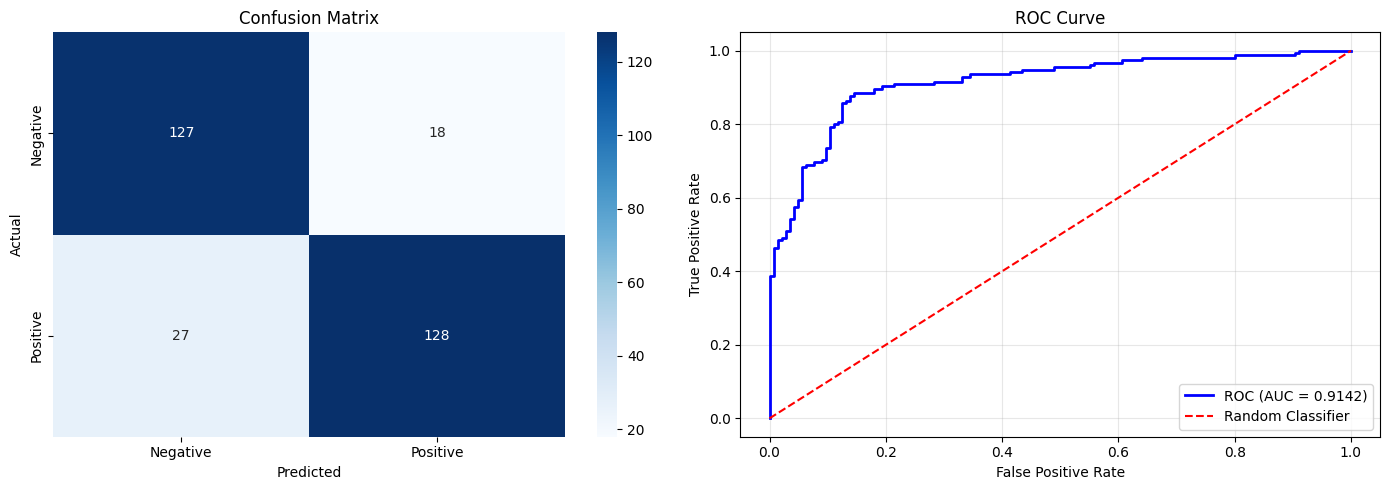

In [19]:
# 10.1 Classification Metrics Deep Dive
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Using our logistic regression predictions
print("📌 Classification Metrics Explained:")
print("=" * 60)

# Train a model for binary classification demo
from sklearn.datasets import make_classification
X_binary, y_binary = make_classification(n_samples=1000, n_features=20, 
                                          n_classes=2, random_state=42)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_binary, y_binary, 
                                                              test_size=0.3, random_state=42)

model_b = LogisticRegression(max_iter=200)
model_b.fit(X_train_b, y_train_b)
y_pred_b = model_b.predict(X_test_b)
y_prob_b = model_b.predict_proba(X_test_b)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_b):.4f}  - Overall correct predictions")
print(f"Precision: {precision_score(y_test_b, y_pred_b):.4f}  - Of predicted positives, how many are correct")
print(f"Recall:    {recall_score(y_test_b, y_pred_b):.4f}  - Of actual positives, how many were found")
print(f"F1 Score:  {f1_score(y_test_b, y_pred_b):.4f}  - Harmonic mean of precision and recall")
print(f"ROC-AUC:   {roc_auc_score(y_test_b, y_prob_b):.4f}  - Area under ROC curve")

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_b, y_prob_b)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_score(y_test_b, y_prob_b):.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 🔧 Module 11: sklearn.pipeline - Creating ML Pipelines

Pipelines chain together multiple steps (preprocessing + model) into a single estimator.

**Benefits:**
- Cleaner code
- Prevents data leakage
- Easier cross-validation
- Simpler deployment

In [20]:
# 11.1 Creating a Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Create a pipeline: Scaling -> SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Step 1: Scale features
    ('svm', SVC(kernel='rbf'))         # Step 2: SVM classifier
])

# Train the pipeline (fits scaler AND model)
pipeline.fit(X_train, y_train)

# Predict (applies scaling AND prediction)
y_pred_pipe = pipeline.predict(X_test)

print("📌 Pipeline Example:")
print(f"Pipeline steps: {pipeline.steps}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_pipe):.4f}")

# Access individual steps
print(f"\nScaler mean: {pipeline.named_steps['scaler'].mean_}")
print(f"SVM n_support: {pipeline.named_steps['svm'].n_support_}")

📌 Pipeline Example:
Pipeline steps: [('scaler', StandardScaler()), ('svm', SVC())]

Accuracy: 0.9667

Scaler mean: [5.84166667 3.04833333 3.77       1.205     ]
SVM n_support: [10 18 19]


---
# 🔍 Module 12: sklearn.model_selection - Hyperparameter Tuning

**GridSearchCV** - Exhaustive search over specified parameter grid
**RandomizedSearchCV** - Random search (faster for large parameter spaces)

In [21]:
# 12.1 GridSearchCV - Finding Best Hyperparameters
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create GridSearchCV
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn, 
    param_grid, 
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',
    return_train_score=True
)

# Fit GridSearch
grid_search.fit(X_train, y_train)

print("📌 GridSearchCV Results:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Use best model
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
print(f"Test Accuracy with Best Model: {accuracy_score(y_test, y_pred_best):.4f}")

# Results as DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
print("\n📊 Top 5 Parameter Combinations:")
results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head()

📌 GridSearchCV Results:
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Score: 0.9750
Test Accuracy with Best Model: 1.0000

📊 Top 5 Parameter Combinations:


,params,mean_test_score,rank_test_score
7,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.975,1
6,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.975,1
5,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.975,1
4,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.975,1
11,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.975,1


---
# 📉 Module 13: sklearn.decomposition - Dimensionality Reduction

**PCA (Principal Component Analysis)** - Reduce dimensions while preserving variance
- Useful for visualization
- Speeds up training
- Reduces overfitting

📌 PCA Results:
Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance ratio: [0.92461872 0.05306648]
Total variance explained: 0.9777


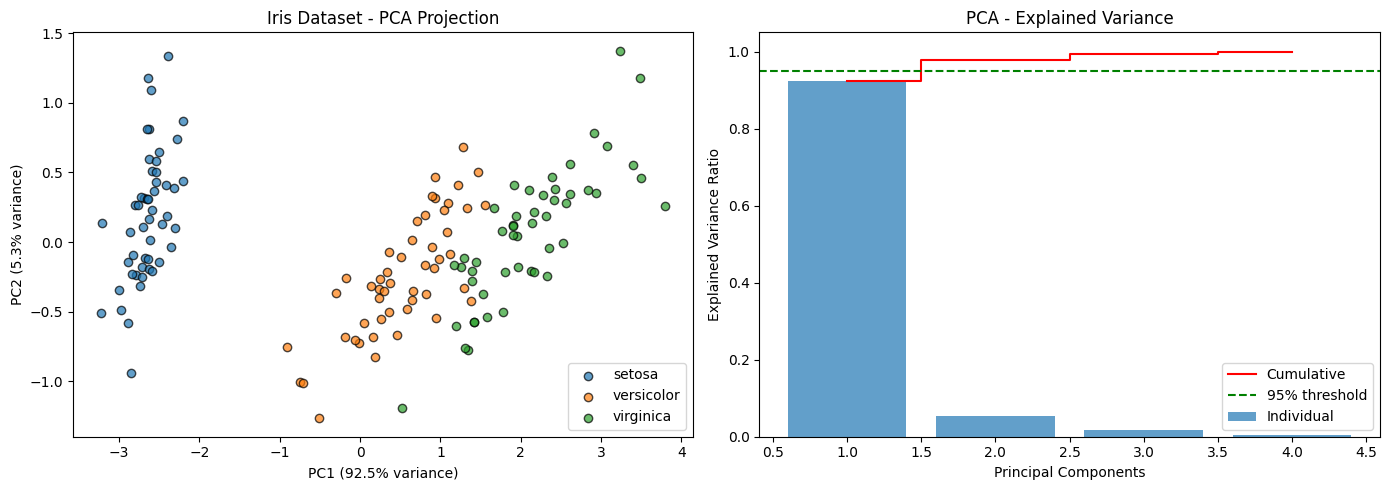

In [22]:
# 13.1 PCA - Principal Component Analysis
from sklearn.decomposition import PCA

# Reduce Iris (4 features) to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("📌 PCA Results:")
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA projection
for i, target_name in enumerate(iris.target_names):
    axes[0].scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target_name, edgecolor='k', alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Iris Dataset - PCA Projection')
axes[0].legend()

# Explained variance
components = range(1, len(iris.feature_names) + 1)
pca_full = PCA().fit(X)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].bar(components, pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[1].step(components, cumulative_var, where='mid', color='red', label='Cumulative')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Principal Components')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA - Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 📝 Module 14: sklearn.feature_extraction - Text Feature Extraction

**For NLP tasks:**
- `CountVectorizer` - Convert text to word counts (Bag of Words)
- `TfidfVectorizer` - Convert text to TF-IDF features

In [23]:
# 14.1 Text Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Sample text data
documents = [
    "Machine learning is amazing",
    "Deep learning is a subset of machine learning",
    "Python is great for machine learning",
    "I love programming in Python",
    "Data science uses machine learning"
]

# CountVectorizer (Bag of Words)
count_vec = CountVectorizer()
count_matrix = count_vec.fit_transform(documents)

print("📌 CountVectorizer (Bag of Words):")
print(f"Vocabulary: {count_vec.get_feature_names_out()}")
print(f"\nDocument-Term Matrix:\n{count_matrix.toarray()}")

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(documents)

print("\n📌 TF-IDF Vectorizer:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vec.get_feature_names_out()
)
print(tfidf_df.round(2))

📌 CountVectorizer (Bag of Words):
Vocabulary: ['amazing' 'data' 'deep' 'for' 'great' 'in' 'is' 'learning' 'love'
 'machine' 'of' 'programming' 'python' 'science' 'subset' 'uses']

Document-Term Matrix:
[[1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 2 0 1 1 0 0 0 1 0]
 [0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0]
 [0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1]]

📌 TF-IDF Vectorizer:
   amazing  data  deep   for  great    in    is  learning  love  machine  \
0     0.69  0.00  0.00  0.00   0.00  0.00  0.46      0.39  0.00     0.39   
1     0.00  0.00  0.45  0.00   0.00  0.00  0.30      0.50  0.00     0.25   
2     0.00  0.00  0.00  0.52   0.52  0.00  0.35      0.29  0.00     0.29   
3     0.00  0.00  0.00  0.00   0.00  0.52  0.00      0.00  0.52     0.00   
4     0.00  0.52  0.00  0.00   0.00  0.00  0.00      0.30  0.00     0.30   

     of  programming  python  science  subset  uses  
0  0.00         0.00    0.00     0.00    0.00  0.00  
1  0.45         0.00    0.00     0.

---
# 💾 Module 15: Saving and Loading Models

Use `joblib` (recommended for sklearn) or `pickle` to save trained models.

In [24]:
# 15.1 Saving and Loading Models with joblib
import joblib
import os

# Create a temp directory for saved models
temp_dir = os.path.join(os.getcwd(), 'saved_models')
os.makedirs(temp_dir, exist_ok=True)

# Save a trained model
model_path = os.path.join(temp_dir, 'random_forest_model.joblib')
joblib.dump(rf_classifier, model_path)
print(f"📌 Model saved to: {model_path}")

# Load the model
loaded_model = joblib.load(model_path)
print("📌 Model loaded successfully!")

# Verify it works
y_pred_loaded = loaded_model.predict(X_test)
print(f"Loaded model accuracy: {accuracy_score(y_test, y_pred_loaded):.4f}")

# Save a complete pipeline
pipeline_path = os.path.join(temp_dir, 'complete_pipeline.joblib')
joblib.dump(pipeline, pipeline_path)
print(f"\n📌 Pipeline also saved to: {pipeline_path}")

# Clean up (optional - remove temp files)
# os.remove(model_path)
# os.remove(pipeline_path)
# os.rmdir(temp_dir)

📌 Model saved to: c:\Users\z0055hnx\Desktop\My Learning Notes\Notes-repo\AI\ML Notes\Lecture 1 Notes\saved_models\random_forest_model.joblib
📌 Model loaded successfully!
Loaded model accuracy: 0.9333

📌 Pipeline also saved to: c:\Users\z0055hnx\Desktop\My Learning Notes\Notes-repo\AI\ML Notes\Lecture 1 Notes\saved_models\complete_pipeline.joblib


---
# 🏆 Module 16: Complete ML Workflow Example

Let's put everything together in a real-world style workflow!

In [25]:
# 16.1 Complete Machine Learning Workflow
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("🏆 COMPLETE ML WORKFLOW EXAMPLE")
print("=" * 60)

# Step 1: Load Data
print("\n📊 Step 1: Loading Wine Dataset...")
wine = load_wine()
X, y = wine.data, wine.target
print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")
print(f"Shape: {X.shape}")

# Step 2: Split Data
print("\n✂️ Step 2: Splitting Data (70% train, 15% val, 15% test)...")
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)
print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# Step 3: Create Pipeline
print("\n🔧 Step 3: Creating Pipeline (Scaler + RandomForest)...")
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Step 4: Hyperparameter Tuning
print("\n🔍 Step 4: Hyperparameter Tuning with GridSearchCV...")
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [3, 5, 10, None],
    'rf__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Step 5: Validate on Validation Set
print("\n✅ Step 5: Validation Set Performance...")
y_val_pred = grid_search.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

# Step 6: Final Evaluation on Test Set
print("\n🎯 Step 6: Final Test Set Evaluation...")
y_test_pred = grid_search.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=wine.target_names))

print("\n🎉 Workflow Complete!")

🏆 COMPLETE ML WORKFLOW EXAMPLE

📊 Step 1: Loading Wine Dataset...
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
Shape: (178, 13)

✂️ Step 2: Splitting Data (70% train, 15% val, 15% test)...
Train: 124, Validation: 27, Test: 27

🔧 Step 3: Creating Pipeline (Scaler + RandomForest)...

🔍 Step 4: Hyperparameter Tuning with GridSearchCV...
Best Parameters: {'rf__max_depth': 5, 'rf__min_samples_split': 5, 'rf__n_estimators': 50}
Best CV Score: 0.9679

✅ Step 5: Validation Set Performance...
Validation Accuracy: 1.0000

🎯 Step 6: Final Test Set Evaluation...
Test Accuracy: 1.0000

📋 Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       1.00      1.00      1.00        11
     class_2    

---
# 📋 Scikit-Learn Cheat Sheet Summary

## 🔄 Typical ML Workflow
```python
# 1. Load Data
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

# 2. Split Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Preprocess
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Note: only transform, don't fit!

# 4. Train Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

# 5. Predict
y_pred = model.predict(X_test_scaled)

# 6. Evaluate
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
```

## 📚 Quick Reference Table

| Task | Module | Common Functions |
|------|--------|------------------|
| Load Data | `sklearn.datasets` | `load_iris()`, `make_classification()` |
| Split Data | `sklearn.model_selection` | `train_test_split()` |
| Scale Features | `sklearn.preprocessing` | `StandardScaler`, `MinMaxScaler` |
| Encode Labels | `sklearn.preprocessing` | `LabelEncoder`, `OneHotEncoder` |
| Classification | `sklearn.linear_model` | `LogisticRegression` |
| Classification | `sklearn.tree` | `DecisionTreeClassifier` |
| Classification | `sklearn.ensemble` | `RandomForestClassifier` |
| Classification | `sklearn.svm` | `SVC` |
| Classification | `sklearn.neighbors` | `KNeighborsClassifier` |
| Regression | `sklearn.linear_model` | `LinearRegression`, `Ridge`, `Lasso` |
| Clustering | `sklearn.cluster` | `KMeans`, `DBSCAN` |
| Dimensionality | `sklearn.decomposition` | `PCA` |
| Metrics | `sklearn.metrics` | `accuracy_score`, `confusion_matrix` |
| Pipelines | `sklearn.pipeline` | `Pipeline`, `make_pipeline` |
| Tuning | `sklearn.model_selection` | `GridSearchCV`, `cross_val_score` |
| Text | `sklearn.feature_extraction.text` | `TfidfVectorizer` |

## 🎯 Key Concepts
- **fit()**: Learn from training data
- **transform()**: Apply learned parameters to data
- **fit_transform()**: fit() + transform() in one step
- **predict()**: Make predictions on new data
- **score()**: Evaluate model performance

## ⚠️ Common Mistakes to Avoid
1. Fitting scaler on test data (data leakage!)
2. Not using stratify in train_test_split for imbalanced data
3. Forgetting to scale features for distance-based algorithms
4. Overfitting by not using cross-validation

---
### 🚀 Happy Learning!